In [1]:
%load_ext autoreload

In [2]:
%autoreload
import torch
from thop import profile
from thop import clever_format

result_dict = {}

# 4LIF_CNN

In [3]:
%autoreload
from models.fourLIF_conv import SCNN_Model_4LIF
model = SCNN_Model_4LIF(2,win=15)
input = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(input,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SCNN_Model_4LIF'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

SCNN_Model_4LIF(
  (task_0): Linear(in_features=50, out_features=10, bias=True)
  (task_1): Linear(in_features=50, out_features=10, bias=True)
  (conv1): Conv2d(1, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=3240, out_features=50, bias=True)
)
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
torch.Size([1, 3240])
unoptimized ops (use thop pkg): 77.145M MACs
[spike op:] add: 79.08835 M ADDops; mul: 80.0604 M MULops


# 4LIF-FC

In [3]:
%autoreload
from models.fourLIF_fc import SNN_Model_4LIF

model = SNN_Model_4LIF(2,win=15)
input = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(input,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SNN_Model_4LIF'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

SNN_Model_4LIF(
  (task_0): Linear(in_features=50, out_features=10, bias=True)
  (task_1): Linear(in_features=50, out_features=10, bias=True)
  (fc1): Linear(in_features=1296, out_features=2048, bias=True)
  (fc): Linear(in_features=2048, out_features=50, bias=True)
)
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
unoptimized ops (use thop pkg): 39.917M MACs
[spike op:] add: 39.97691 M ADDops; mul: 40.00768 M MULops


# LIF-CNN

In [ ]:
%autoreload
from models.LIF_conv import SCNN_Model_LIF

model = SCNN_Model_LIF(2,win=15)
input = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(input,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SCNN_Model_LIF'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

# LIF-FC

In [4]:
%autoreload
from models.LIF_fc import SNN_Model_LIF

model = SNN_Model_LIF(2,win=15)
input = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(input,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SNN_Model_LIF'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

SNN_Model_LIF(
  (task_0): Linear(in_features=50, out_features=10, bias=True)
  (task_1): Linear(in_features=50, out_features=10, bias=True)
  (fc1): Linear(in_features=1296, out_features=512, bias=True)
  (fc): Linear(in_features=512, out_features=50, bias=True)
)
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
unoptimized ops (use thop pkg): 9.980M MACs
[spike op:] add: 9.99419 M ADDops; mul: 10.00192 M MULops


# HH_conv

In [ ]:
%autoreload
from models.HH_conv import SCNN_Model_HH

model = SCNN_Model_HH(2,win=15)
input = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(input,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SCNN_Model_HH'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

# HH_fc

In [5]:
%autoreload
from models.HH_fc import SNN_Model_HH

model = SNN_Model_HH(2,win=15)
input = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(input,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SNN_Model_HH'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

SNN_Model_HH(
  (task_0): Linear(in_features=50, out_features=10, bias=True)
  (task_1): Linear(in_features=50, out_features=10, bias=True)
  (fc1): HH_neuron(
    (fc): Linear(in_features=1296, out_features=512, bias=True)
  )
  (fc_output): Linear(in_features=512, out_features=50, bias=True)
)
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
unoptimized ops (use thop pkg): 9.980M MACs
[spike op:] add: 10.09403 M ADDops; mul: 10.15552 M MULops


# LIF_HH_CONV

In [ ]:
%autoreload
from thop import profile
from thop import clever_format
from models.LIF_hh_conv import SCNN_Model_LIF_hh

model = SCNN_Model_LIF_hh(2,win=15)
inputs = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(inputs,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SCNN_Model_LIF_hh'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

# LIF_HH_FC

In [6]:
%autoreload
from models.LIF_hh_fc import SNN_Model_LIF_hh

model = SNN_Model_LIF_hh(2,win=15)
input = torch.randn(1, 1, 36, 36)
macs, params = profile(model, inputs=(input,))
macs, params = clever_format([macs, params], "%.3f")
print('unoptimized ops (use thop pkg):',macs,'MACs')
print('[spike op:] add:',model.add_op/1e6,'M ADDops; mul:',model.mul_op/1e6,'M MULops')
result_dict['SNN_Model_LIF_hh'] = (float(model.add_op/1e6),float(model.mul_op/1e6))

SNN_Model_LIF_hh(
  (task_0): Linear(in_features=50, out_features=10, bias=True)
  (task_1): Linear(in_features=50, out_features=10, bias=True)
  (fc_output): Linear(in_features=2048, out_features=50, bias=True)
  (lif_4): lif_hh(
    (fc1): Linear(in_features=1296, out_features=512, bias=True)
    (fc2): Linear(in_features=1296, out_features=512, bias=True)
    (fc3): Linear(in_features=1296, out_features=512, bias=True)
    (lif_fc): Linear(in_features=3, out_features=1, bias=True)
  )
)
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
unoptimized ops (use thop pkg): 29.986M MACs
[spike op:] add: 30.04667 M ADDops; mul: 30.07744 M MULops


# 4-LIF / 5-LIF mem-mixing topologies (fc + conv)

Profiling 4-LIF (1+3, 2+2, 1+2+1, 1+1+1+1, ring) and 5-LIF (1+3+1, 1+1+3, 1+2+2, 1+1+2+1, 1+1+1+1+1, 1+4) variants. Both fc and conv versions.

These models are copied from `multi-task/models/models_*LIF_*` and adapted for cpu profiling. Op counting is done by `OpsTracker`, which wraps `nn.Linear.forward` / `nn.Conv2d.forward` to count multiply-add ops per call. Per-step neuron-internal ops (LIF mem/spike update, ~3 per element per slot per step) are added separately to match the existing `fourLIF_fc.py` / `fourLIF_conv.py` accounting style.

In [7]:
%autoreload
import sys, importlib, torch
sys.path.insert(0, '.')
from ops_tracker import OpsTracker, spike_op_per_step

# cfg: slot_count=4, win=15, fc_dim=512
fc_4LIF = ['LIF_1_1_1_1', 'LIF_1_2_1', 'LIF_1_3', 'LIF_2_2']  # , 'LIF_ring'
slot_count, win, fc_dim = 4, 15, 512

for name in fc_4LIF:
    mod = importlib.import_module(f'models.models_4LIF_fc.{name}_fc')
    cls = getattr(mod, f'SNN_Model_{name}')
    m = cls(2)
    x = torch.randn(1, 1, 36, 36)
    with OpsTracker(m) as t:
        _ = m(x)
    spike = spike_op_per_step(slot_count, fc_dim, [], win, [], is_conv=False, n_lif_layers=1)
    add_m = (t.add_op + spike) / 1e6
    mul_m = (t.mul_op + spike) / 1e6
    print(f'[{name}] [spike op:] add: {add_m:.3f} M ADDops; mul: {mul_m:.3f} M MULops')
    result_dict[f'SNN_Model_{name}'] = (float(add_m), float(mul_m))

[LIF_1_1_1_1] [spike op:] add: 10.141 M ADDops; mul: 10.149 M MULops
[LIF_1_2_1] [spike op:] add: 10.141 M ADDops; mul: 10.149 M MULops
[LIF_1_3] [spike op:] add: 10.141 M ADDops; mul: 10.149 M MULops
[LIF_2_2] [spike op:] add: 20.087 M ADDops; mul: 20.102 M MULops


In [8]:
%autoreload
fc_5LIF = ['LIF_1_1_1_1_1', 'LIF_1_1_2_1', 'LIF_1_1_3', 'LIF_1_2_2', 'LIF_1_3_1', 'LIF_1_4']
slot_count, win, fc_dim = 5, 15, 512

for name in fc_5LIF:
    mod = importlib.import_module(f'models.models_5LIF_fc.{name}_fc')
    cls = getattr(mod, f'SNN_Model_{name}')
    m = cls(2)
    x = torch.randn(1, 1, 36, 36)
    with OpsTracker(m) as t:
        _ = m(x)
    spike = spike_op_per_step(slot_count, fc_dim, [], win, [], is_conv=False, n_lif_layers=1)
    add_m = (t.add_op + spike) / 1e6
    mul_m = (t.mul_op + spike) / 1e6
    print(f'[{name}][spike op:] add: {add_m:.3f} M ADDops; mul: {mul_m:.3f} M MULops')
    result_dict[f'SNN_Model_{name}'] = (float(add_m), float(mul_m))

[LIF_1_1_1_1_1][spike op:] add: 10.190 M ADDops; mul: 10.198 M MULops
[LIF_1_1_2_1][spike op:] add: 10.190 M ADDops; mul: 10.198 M MULops
[LIF_1_1_3][spike op:] add: 10.190 M ADDops; mul: 10.198 M MULops
[LIF_1_2_2][spike op:] add: 10.190 M ADDops; mul: 10.198 M MULops
[LIF_1_3_1][spike op:] add: 10.190 M ADDops; mul: 10.198 M MULops
[LIF_1_4][spike op:] add: 10.190 M ADDops; mul: 10.198 M MULops


In [ ]:
%autoreload
conv_4LIF = ['LIF_1_1_1_1', 'LIF_1_2_1', 'LIF_1_3', 'LIF_2_2'] # , 'LIF_ring'
slot_count, win = 4, 10  # conv models use time_window=10
kernel_dims = [36, 18]  # c1: 36x36, c2: 18x18
conv_channels = [10, 10]  # both conv layers have 10 channels

for name in conv_4LIF:
    mod = importlib.import_module(f'models.models_4LIF_conv.{name}_conv')
    cls = getattr(mod, f'SCNN_Model_{name}')
    m = cls(2)
    x = torch.randn(1, 1, 36, 36)
    with OpsTracker(m) as t:
        _ = m(x)
    spike = spike_op_per_step(slot_count, 0, kernel_dims, win, conv_channels,
                               is_conv=True, n_lif_layers=2)
    add_m = (t.add_op + spike) / 1e6
    mul_m = (t.mul_op + spike) / 1e6
    print(f'[spike op:] add: {add_m:.3f} M ADDops; mul: {mul_m:.3f} M MULops')
    result_dict[f'SCNN_Model_{name}'] = (float(add_m), float(mul_m))

In [ ]:
%autoreload
conv_5LIF = ['LIF_1_1_1_1_1', 'LIF_1_1_2_1', 'LIF_1_1_3', 'LIF_1_2_2', 'LIF_1_3_1', 'LIF_1_4']
slot_count, win = 5, 10
kernel_dims = [36, 18]
conv_channels = [10, 10]

for name in conv_5LIF:
    mod = importlib.import_module(f'models.models_5LIF_conv.{name}_conv')
    cls = getattr(mod, f'SCNN_Model_{name}')
    m = cls(2)
    x = torch.randn(1, 1, 36, 36)
    with OpsTracker(m) as t:
        _ = m(x)
    spike = spike_op_per_step(slot_count, 0, kernel_dims, win, conv_channels,
                               is_conv=True, n_lif_layers=2)
    add_m = (t.add_op + spike) / 1e6
    mul_m = (t.mul_op + spike) / 1e6
    print(f'[spike op:] add: {add_m:.3f} M ADDops; mul: {mul_m:.3f} M MULops')
    result_dict[f'SCNN_Model_{name}'] = (float(add_m), float(mul_m))

{'SNN_Model_4LIF': (39.97691, 40.00768), 'SNN_Model_LIF': (9.99419, 10.00192), 'SNN_Model_HH': (10.09403, 10.15552), 'SNN_Model_LIF_hh': (30.04667, 30.07744), 'SNN_Model_LIF_1_1_1_1': (10.14109, 10.148885), 'SNN_Model_LIF_1_2_1': (10.141105, 10.1489), 'SNN_Model_LIF_1_3': (10.14109, 10.148885), 'SNN_Model_LIF_2_2': (20.08672, 20.10218), 'SNN_Model_LIF_1_1_1_1_1': (10.18973, 10.19754), 'SNN_Model_LIF_1_1_2_1': (10.189745, 10.197555), 'SNN_Model_LIF_1_1_3': (10.18973, 10.19754), 'SNN_Model_LIF_1_2_2': (10.18976, 10.19757), 'SNN_Model_LIF_1_3_1': (10.18976, 10.19757), 'SNN_Model_LIF_1_4': (10.18973, 10.19754)}


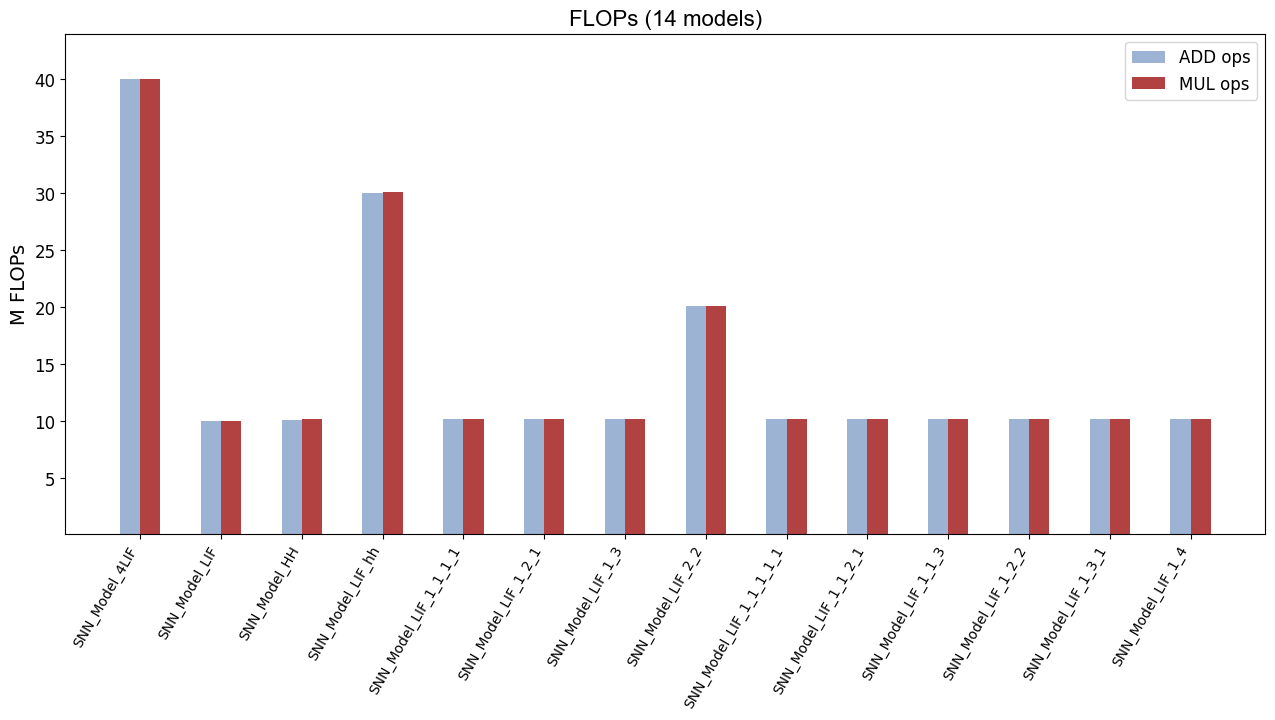

In [10]:
import matplotlib.pyplot as plt
import numpy as np
print(result_dict)

# 准备数据
n_models = len(result_dict)
fig = plt.figure(figsize=(max(12, 0.5 * n_models), 5))
ax = fig.add_axes([0, 0, 1, 1])

index, label, count = [], [], 0
color_dict = [[0.6980, 0.2588, 0.2549],
    [0.7961, 0.4314, 0.4549],
    [0.9098, 0.6627, 0.6510],
    [0.1333, 0.1412, 0.2863],
    [0.2549, 0.2980, 0.5294],
    [0.6118, 0.7020, 0.8314]]
color1 = color_dict[5]  # ADD ops
color2 = color_dict[0]  # MUL ops
for key in result_dict:
    data = result_dict[key]
    if count == 0:
        ax.bar(count - 0.125, data[0], color=color1, width=0.25, label='ADD ops')
        ax.bar(count + 0.125, data[1], color=color2, width=0.25, label='MUL ops')
    else:
        ax.bar(count - 0.125, data[0], color=color1, width=0.25)
        ax.bar(count + 0.125, data[1], color=color2, width=0.25)
    index.append(count)
    label.append(key)
    count += 1

plt.xticks(index, label, rotation=60, fontsize=10, ha='right')
max_val = max(max(d) for d in result_dict.values())
plt.ylim(0.1, max_val * 1.1)
plt.yticks(fontsize=12)
# plt.yscale('log')
plt.legend(fontsize=12)
plt.ylabel('M FLOPs', fontsize=14)
plt.title(f'FLOPs ({n_models} models)', fontsize=16, family='Arial')
# plt.show()
plt.savefig('result.svg', bbox_inches='tight')
